Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


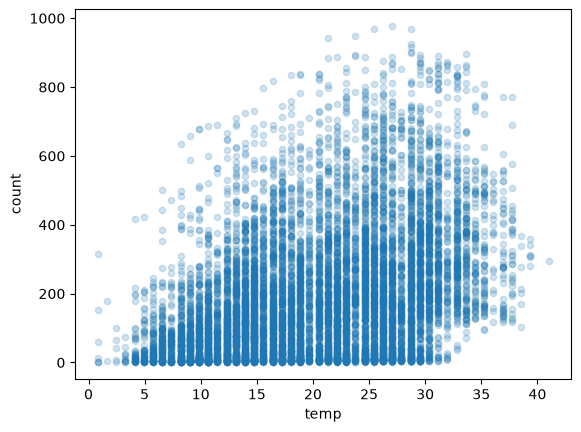

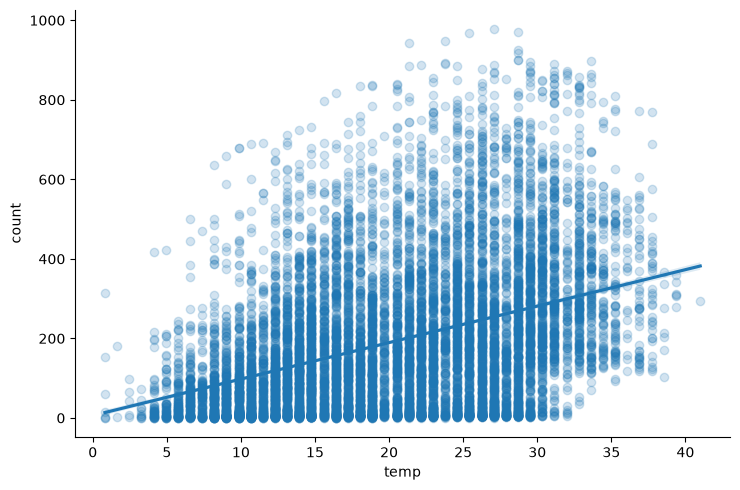

                  datetime  season  holiday  workingday  weather   temp  \
0      2011-01-01 00:00:00       1        0           0        1   9.84   
1      2011-01-01 01:00:00       1        0           0        1   9.02   
2      2011-01-01 02:00:00       1        0           0        1   9.02   
3      2011-01-01 03:00:00       1        0           0        1   9.84   
4      2011-01-01 04:00:00       1        0           0        1   9.84   
...                    ...     ...      ...         ...      ...    ...   
10881  2012-12-19 19:00:00       4        0           1        1  15.58   
10882  2012-12-19 20:00:00       4        0           1        1  14.76   
10883  2012-12-19 21:00:00       4        0           1        1  13.94   
10884  2012-12-19 22:00:00       4        0           1        1  13.94   
10885  2012-12-19 23:00:00       4        0           1        1  13.12   

        atemp  humidity  windspeed  casual  registered  count  
0      14.395        81     0.0000 

In [14]:
%pip install seaborn

%pip install requests

import pandas as pd
import matplotlib.pyplot as plt
import requests
import seaborn as sns
import io

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/bikeshare.csv"
response = requests.get(url)
response.raise_for_status()

bikes = pd.read_csv(io.StringIO(response.text))
print(bikes.head())
bikes.plot(kind='scatter', x='temp', y='count', alpha=0.2)

sns.lmplot(
	x='temp',
	y='count',
	data=bikes,
	aspect=1.5,
	scatter_kws={'alpha': 0.2}
)

plt.show()
print(bikes, 'count')


In [15]:
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import LinearRegression
# from sklearn.model_selection import mean_squared_error
# import numpy as np
# feature_cols = ['temp']
# X = bikes[feature_cols]
# y = bikes['count']
# X_train, X_test, y_treain


In [16]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

linreg = LinearRegression()

feature_cols = ['temp', 'season', 'weather', 'humidity']
X = bikes[feature_cols]
y = bikes['count']

linreg.fit(X, y)
y_pred = linreg.predict(X)

print(np.sqrt(mean_squared_error(y, y_pred)))



155.99832684186404


In [18]:
from sklearn import metrics

feature_cols = ['temp', 'humidity', 'season', 'holiday', 'workingday', 'windspeed', 'weather', 'atemp']
X = bikes[feature_cols]
linreg = LinearRegression()
linreg.fit(X, y)
y_pred = linreg.predict(X)
print(np.sqrt(metrics.mean_squared_error(y, y_pred)))


155.72309569370316


In [ ]:
import numpy as np
r1 = np.array([1, 3])
r1 = np.array([2, 5])
r1 = np.array([3, 4])
center = (r1 + r2 + r3) / 3
print(center)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = np.array([[1, 2], [1.5, 2], [5, 8], [8, 8], [1, 0.6], [9, 11]])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(data)

centroids = kmeans.cluster_centers_
labels = kmeans.labels_

plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='red', marker='X')
plt.title("K-Means Clustering Example")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


/var/folders/t6/c7q75lr513j39v1sgl1fj9zw0000gn/T/ipykernel_2865/2576632084.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:, 0], X[:, 1], s=30, cmap='viridis')


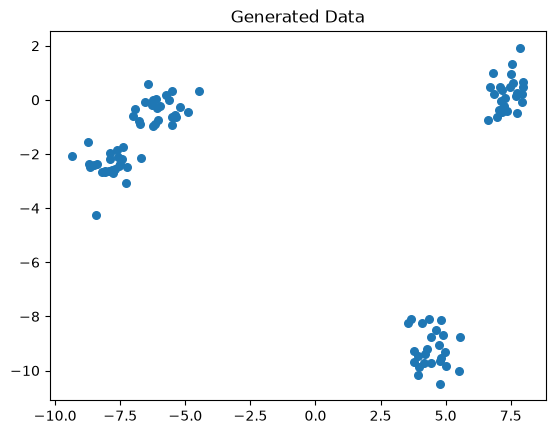

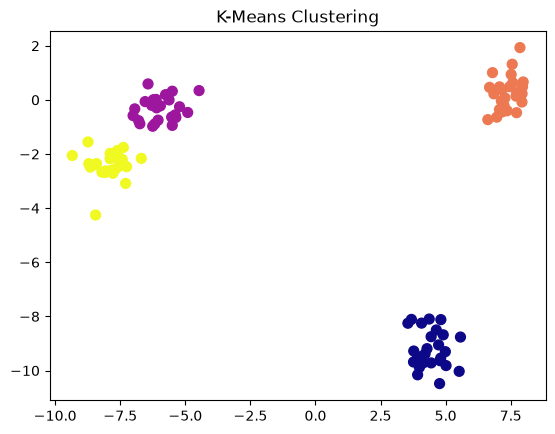

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

X, y = make_blobs(n_samples = 100, centers = 4, cluster_std = 0.6)
plt.scatter(X[:, 0], X[:, 1], s=30, cmap='viridis')
plt.title("Generated Data")
plt.show()
kmeans = KMeans(n_clusters = 4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
plt.scatter(X[:, 0], X[:, 1], c = y_kmeans, s = 50, cmap = 'plasma')
plt.title("K-Means Clustering")
plt.show()


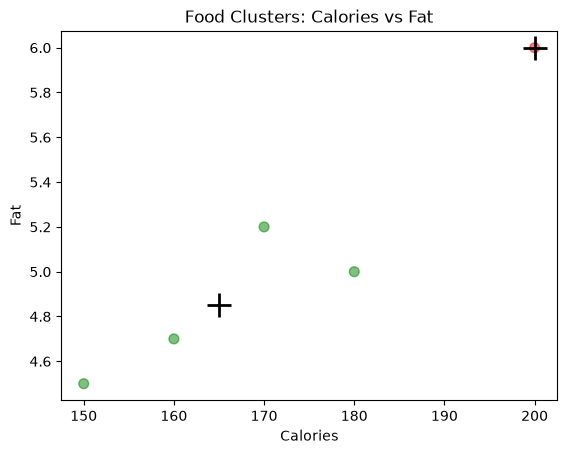

In [22]:
data = {
    'name':['food1', 'food2', 'food3', 'food4', 'food5'],
    'calories':[150, 180, 160, 200, 170],
    'fat':[4.5, 5.0, 4.7, 6.0, 5.2],
    'sugar':[10, 12, 9, 15, 11],
    'sodium':[20, 25, 22, 30, 24]
}

food = pd.DataFrame(data)
X = food.drop('name', axis = 1)
km = KMeans(n_clusters = 2)
km.fit(X)
food['cluster'] = km.labels_
centers = food.drop('name', axis = 1).groupby(food['cluster']).mean()
colors = np.array(['red', 'green', 'blue', 'yellow'])
plt.figure()
plt.scatter(food.calories, food.fat, c = colors[food.cluster.values], s = 50, alpha = 0.5)
plt.scatter(centers.calories, centers.fat, marker = '+', s = 300, c = 'black', linewidth = 2)
plt.xlabel('Calories')
plt.ylabel('Fat')
plt.title('Food Clusters: Calories vs Fat')
plt.show()


(1797, 64)


NameError: name 'cluster_name' is not defined

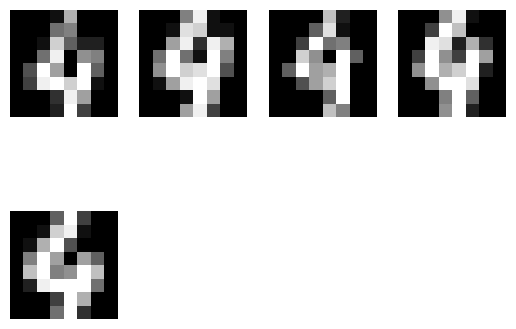

In [25]:
from sklearn.datasets import load_digits

digits = load_digits()
X = digits.data
y = digits.target
print(X.shape)
kmeans = KMeans(n_clusters = 10)
clusters = kmeans.fit_predict(X)

def plot_cluster(cluster_num):
    indices = np.where(clusters == cluster_num)[0]
    plt.figure()
    for i, idx in enumerate(indices[:5]):
        plt.subplot(2, 4, i + 1)
        plt.imshow(digits.images[idx], cmap = 'gray')
        plt.axis('off')
    plt.suptitle(f'Cluster {cluster_name} Images')
    plt.show()

for c in range(3):
    plot_cluster(c)


Shape of images array: (10, 8, 8)


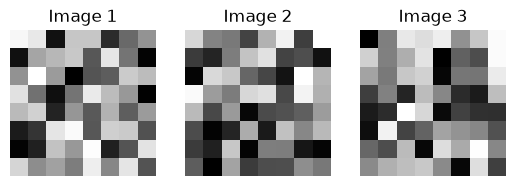

PCA transformed shape: (10, 2)
Explained variance ration: [0.19565018 0.14013708]


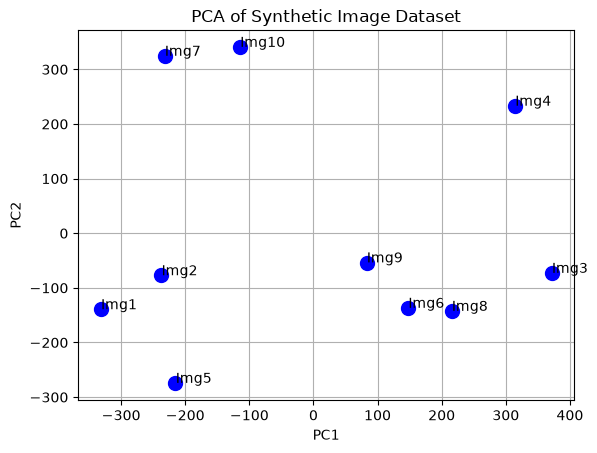

In [26]:
import random
from sklearn.decomposition import PCA
n_images = 10
h, w = 8, 8

images = np.random.randint(0, 256, size = (n_images, h, w))
print("Shape of images array:", images.shape)
fig, axes = plt.subplots(1, 3)
for i in range(3):
    axes[i].imshow(images[i], cmap = 'gray')
    axes[i].set_title(f'Image {i + 1}')
    axes[i].axis('off')
plt.show()
X = images.reshape(n_images, h * w)
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)
print("PCA transformed shape:", X_pca.shape)
print("Explained variance ration:", pca.explained_variance_ratio_)
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c = 'blue', s = 100)
for i in range(n_images):
    plt.annotate(f'Img{i + 1}', (X_pca[i, 0] + 0.5, X_pca[i, 1] + 0.5))
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Synthetic Image Dataset')
plt.grid(True)
plt.show()


Training set shape: (14, 64)
Testing set shape: (6, 64)

Transformed training shape: (14, 5)
Explained variance ratio (train): [0.14802306 0.12222469 0.11217459 0.09556803 0.0902106 ]
Transformed testing shape: (14, 5)


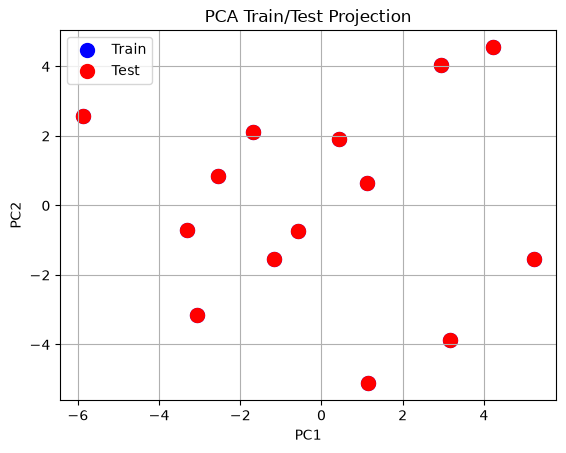

In [30]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

n_images = 20
h, w = 8, 8
images = np.random.randint(0, 256, size = (n_images, h, w))
X = images.reshape(n_images, h * w)
X_train, X_test = train_test_split(X, test_size = 0.3)
print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pca = PCA(n_components = 5)
X_train_pca = pca.fit_transform(X_train_scaled)
print("\nTransformed training shape:", X_train_pca.shape)
print("Explained variance ratio (train):", pca.explained_variance_ratio_)
X_test_pca = pca.fit_transform(X_train_scaled)
print("Transformed testing shape:", X_test_pca.shape)
plt.figure()
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c = 'blue', label = 'Train', s = 100)
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c = 'red', label = 'Test', s = 100)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Train/Test Projection')
plt.legend()
plt.grid(True)
plt.show()
